# Multimodal Sentiment Analysis: Fusion Models

Building on the best text-only encoder from notebook 02, this notebook experiments with three fusion strategies that combine all three modalities (text, audio, visual).

| Strategy | Description |
|----------|-------------|
| **Early Fusion** | Concatenate the three feature streams on the *feature dimension* before any encoder, then process the joint sequence with a single BiGRU |
| **Late Fusion** | Encode each modality separately with a BiGRU, concatenate the three representations, then apply a shared prediction head |
| **Low-Rank Tensor Fusion (LRTF)** | Encode each modality separately, then apply low-rank tensor decomposition to model multiplicative cross-modal interactions |

All models use L1 (MAE) loss and are evaluated with the same MOSEI metrics as notebook 02.

In [10]:
import sys
import os
import random
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import f1_score

MULTIBENCH = os.path.join("..", "external", "MultiBench")
sys.path.insert(0, MULTIBENCH)

from datasets.affect.get_data import get_dataloader

import torch
import torch.nn as nn

# --- reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs("../results", exist_ok=True)
os.makedirs("../models",  exist_ok=True)
os.makedirs("../figures", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  |  seed: {SEED}")

Device: cpu  |  seed: 42


In [11]:
DATA_PATH = os.path.join(MULTIBENCH, "datasets", "affect", "pack", "mosei", "mosei_senti_data.pkl")

traindata, validdata, testdata = get_dataloader(
    DATA_PATH, data_type="mosei", max_pad=True, max_seq_len=40, batch_size=32
)

n_train = sum(b[-1].shape[0] for b in traindata)
n_valid = sum(b[-1].shape[0] for b in validdata)
n_test  = sum(b[-1].shape[0] for b in testdata)
print(f"Train: {n_train}  Valid: {n_valid}  Test: {n_test}")

Train: 16265  Valid: 1869  Test: 4643


## Shared utilities

In [12]:
def compute_metrics(preds, labels):
    preds  = np.array(preds)
    labels = np.array(labels)
    mae  = np.mean(np.abs(preds - labels))
    mse  = np.mean((preds - labels) ** 2)
    corr = pearsonr(preds, labels)[0]
    nz = labels != 0
    preds_bin  = (preds[nz]  > 0).astype(int)
    labels_bin = (labels[nz] > 0).astype(int)
    acc2 = np.mean(preds_bin == labels_bin)
    f1   = f1_score(labels_bin, preds_bin, average='weighted')
    return {"MAE": mae, "MSE": mse, "Pearson_r": corr, "Acc_2": acc2, "F1": f1}


def evaluate_multimodal(model, loader, device=DEVICE):
    """Inference for models that accept (vision, audio, text) as separate arguments."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            vision = batch[0].float().to(device)
            audio  = batch[1].float().to(device)
            text   = batch[2].float().to(device)
            labels = batch[3].float().to(device)
            preds  = model(vision, audio, text).squeeze(-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.squeeze().cpu().tolist())
    metrics = compute_metrics(all_preds, all_labels)
    metrics['preds']  = np.array(all_preds)
    metrics['labels'] = np.array(all_labels)
    return metrics


def train_multimodal(model, traindata, validdata, n_epochs=50, lr=1e-3,
                     weight_decay=1e-4, patience=8, save_path=None, device=DEVICE):
    """Training loop for models that accept (vision, audio, text)."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.L1Loss()
    model.to(device)

    best_val = float('inf')
    wait = 0
    train_hist, val_hist = [], []

    for epoch in range(n_epochs):
        model.train()
        running_loss, n = 0.0, 0
        for batch in traindata:
            vision = batch[0].float().to(device)
            audio  = batch[1].float().to(device)
            text   = batch[2].float().to(device)
            y      = batch[3].float().to(device)
            pred   = model(vision, audio, text)
            loss   = criterion(pred, y)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item() * y.shape[0]
            n += y.shape[0]
        train_hist.append(running_loss / n)

        model.eval()
        val_loss, nv = 0.0, 0
        with torch.no_grad():
            for batch in validdata:
                vision = batch[0].float().to(device)
                audio  = batch[1].float().to(device)
                text   = batch[2].float().to(device)
                y      = batch[3].float().to(device)
                pred   = model(vision, audio, text)
                val_loss += criterion(pred, y).item() * y.shape[0]
                nv += y.shape[0]
        val_hist.append(val_loss / nv)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | train MAE: {train_hist[-1]:.4f}  val MAE: {val_hist[-1]:.4f}")

        if val_hist[-1] < best_val:
            best_val = val_hist[-1]
            wait = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {epoch+1}")
                break

    if save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))

    return train_hist, val_hist


print("Utilities loaded.")

Utilities loaded.


## 1. Early Fusion

All three feature streams are concatenated along the feature dimension at each time step:

$$\mathbf{x}_t = [\mathbf{v}_t ; \mathbf{a}_t ; \mathbf{t}_t] \in \mathbb{R}^{35+74+300=409}$$

The concatenated sequence is then passed through a bidirectional GRU, and the final hidden state is projected to a scalar sentiment score.

In [14]:
class EarlyFusionModel(nn.Module):
    """Concatenate modalities on feature dim, encode with BiGRU."""
    def __init__(self,
                 v_dim=35, a_dim=74, t_dim=300,
                 hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        fused_dim = v_dim + a_dim + t_dim   # 409
        self.gru = nn.GRU(
            fused_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim * 2, 1)

    def forward(self, vision, audio, text):
        # vision: (B, T, 35)  audio: (B, T, 74)  text: (B, T, 300)
        x = torch.cat([vision, audio, text], dim=-1)   # (B, T, 409)
        _, h = self.gru(x)                              # h: (num_layers*2, B, hidden)
        h_cat = torch.cat([h[-2], h[-1]], dim=-1)       # (B, hidden*2)
        return self.head(self.drop(h_cat))               # (B, 1)


print("Training Early Fusion...")
ef_model = EarlyFusionModel().to(DEVICE)
ef_train_h, ef_val_h = train_multimodal(
    ef_model, traindata, validdata,
    n_epochs=50, lr=1e-3, patience=8,
    save_path="../models/early_fusion.pt"
)
ef_metrics = evaluate_multimodal(ef_model, testdata)
print("\nEarly Fusion (test):")
for k, v in ef_metrics.items():
    if k not in ('preds', 'labels'):
        print(f"  {k}: {v:.4f}")

Training Early Fusion...
  Epoch  10 | train MAE: 0.6054  val MAE: 0.6134
  Epoch  20 | train MAE: 0.5347  val MAE: 0.6416
  Epoch  30 | train MAE: 0.4776  val MAE: 0.6070
  Early stop at epoch 31

Early Fusion (test):
  MAE: 0.6293
  MSE: 0.7289
  Pearson_r: 0.6471
  Acc_2: 0.7876
  F1: 0.7796


## 2. Late Fusion

Each modality is encoded *independently* by its own BiGRU:

$$\mathbf{r}^{(m)} = \text{BiGRU}_m(\mathbf{X}^{(m)}), \quad m \in \{v, a, t\}$$

The three representations are concatenated and passed through a shared prediction head:

$$\hat{y} = \text{MLP}([\mathbf{r}^{(v)} ; \mathbf{r}^{(a)} ; \mathbf{r}^{(t)}])$$

This approach preserves modality-specific features until the very end.

In [ ]:
class ModalityEncoder(nn.Module):
    """Single-modality BiGRU encoder."""
    def __init__(self, input_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_dim, hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        _, h = self.gru(x)                  # h: (4, B, hidden)
        return self.drop(torch.cat([h[-2], h[-1]], dim=-1))  # (B, hidden*2)


class LateFusionModel(nn.Module):
    """Separate BiGRU per modality, shared head on concatenated representations."""
    def __init__(self,
                 v_dim=35, a_dim=74, t_dim=300,
                 hidden_dim=64, dropout=0.3):
        super().__init__()
        self.enc_v = ModalityEncoder(v_dim, hidden_dim, dropout)
        self.enc_a = ModalityEncoder(a_dim, hidden_dim, dropout)
        self.enc_t = ModalityEncoder(t_dim, hidden_dim, dropout)
        fused = hidden_dim * 2 * 3   # 3 modalities × bidirectional
        self.head = nn.Sequential(
            nn.Linear(fused, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, vision, audio, text):
        r_v = self.enc_v(vision)   # (B, hidden*2)
        r_a = self.enc_a(audio)    # (B, hidden*2)
        r_t = self.enc_t(text)     # (B, hidden*2)
        fused = torch.cat([r_v, r_a, r_t], dim=-1)  # (B, hidden*6)
        return self.head(fused)                       # (B, 1)

    def unimodal_preds(self, vision, audio, text):
        """Return scalar predictions from each modality encoder independently."""
        r_v = self.enc_v(vision)
        r_a = self.enc_a(audio)
        r_t = self.enc_t(text)
        # Project each to 1D using a simple linear layer for analysis
        return r_v, r_a, r_t


print("Training Late Fusion...")
lf_model = LateFusionModel().to(DEVICE)
lf_train_h, lf_val_h = train_multimodal(
    lf_model, traindata, validdata,
    n_epochs=50, lr=1e-3, patience=8,
    save_path="../models/late_fusion.pt"
)
lf_metrics = evaluate_multimodal(lf_model, testdata)
print("\nLate Fusion (test):")
for k, v in lf_metrics.items():
    if k not in ('preds', 'labels'):
        print(f"  {k}: {v:.4f}")

Training Late Fusion...
  Epoch  10 | train MAE: 0.4719  val MAE: 0.5985
  Early stop at epoch 12

Late Fusion (test):
  MAE: 0.6111
  MSE: 0.6764
  Pearson_r: 0.6749
  Acc_2: 0.8080
  F1: 0.8072


## 3. Low-Rank Tensor Fusion (LRTF)

Instead of simple concatenation, LRTF (Zadeh et al., 2017; Liu et al., 2018) explicitly models multiplicative interactions between all modality pairs by factorising the full outer-product tensor with rank-$R$ matrices:

$$\hat{y} = \mathbf{w}^\top \left( \sum_{r=1}^R \bigotimes_{m} \mathbf{W}_r^{(m)} \tilde{\mathbf{r}}^{(m)} \right) + b$$

where $\tilde{\mathbf{r}}^{(m)} = [1; \mathbf{r}^{(m)}]$ (appended bias unit) and $\bigotimes$ denotes the outer product.

The MultiBench implementation is used, with a fix to register the factor matrices as `nn.ParameterList`.

In [ ]:
class LowRankTensorFusion(nn.Module):
    """
    Fixed implementation of Low-Rank Tensor Fusion.
    The original MultiBench code stores factors in a plain list, preventing
    them from being registered as trainable parameters. Here we use nn.ParameterList.
    """
    def __init__(self, input_dims, output_dim, rank):
        """
        Args:
            input_dims: list of encoder output dimensions (one per modality)
            output_dim: hidden dimension of the fused representation
            rank: low-rank decomposition rank R
        """
        super().__init__()
        self.rank = rank
        self.output_dim = output_dim
        # one factor matrix per modality: shape (rank, input_dim+1, output_dim)
        self.factors = nn.ParameterList([
            nn.Parameter(torch.empty(rank, d + 1, output_dim))
            for d in input_dims
        ])
        self.fusion_weights = nn.Parameter(torch.empty(1, rank))
        self.fusion_bias    = nn.Parameter(torch.zeros(1, output_dim))
        for factor in self.factors:
            nn.init.xavier_normal_(factor)
        nn.init.xavier_normal_(self.fusion_weights)

    def forward(self, modalities):
        batch_size = modalities[0].shape[0]
        fused = torch.ones(batch_size, self.rank, self.output_dim,
                           device=modalities[0].device)
        for x, factor in zip(modalities, self.factors):
            ones = torch.ones(batch_size, 1, device=x.device)
            x_aug = torch.cat([ones, x], dim=1)         # (B, d+1)
            projected = torch.einsum('bi,rio->bro', x_aug, factor)  # (B, rank, output)
            fused = fused * projected
        # Weighted sum over rank dimension
        output = torch.einsum('br,bro->bo', self.fusion_weights.expand(batch_size, -1), fused)
        return output + self.fusion_bias


class LRTFModel(nn.Module):
    """Unimodal BiGRU encoders + Low-Rank Tensor Fusion + linear head."""
    def __init__(self,
                 v_dim=35, a_dim=74, t_dim=300,
                 enc_dim=32, fusion_out=64, rank=4, dropout=0.3):
        super().__init__()
        # Lighter encoders: single-layer GRU with linear projection
        self.enc_v = nn.Sequential(
            nn.GRU(v_dim,  enc_dim, batch_first=True, bidirectional=True),
        )
        self.enc_a = nn.Sequential(
            nn.GRU(a_dim,  enc_dim * 2, batch_first=True, bidirectional=True),
        )
        self.enc_t = nn.Sequential(
            nn.GRU(t_dim,  enc_dim * 4, batch_first=True, bidirectional=True),
        )
        v_out = enc_dim * 2
        a_out = enc_dim * 4
        t_out = enc_dim * 8
        self.lrtf = LowRankTensorFusion([v_out, a_out, t_out], fusion_out, rank)
        self.head  = nn.Linear(fusion_out, 1)
        self.drop  = nn.Dropout(dropout)

    def _encode(self, encoder_seq, x):
        """Run the GRU and return last hidden state (forward + backward)."""
        gru = encoder_seq[0]
        _, h = gru(x)                              # h: (2, B, hidden)
        return torch.cat([h[0], h[1]], dim=-1)     # (B, hidden*2)

    def forward(self, vision, audio, text):
        r_v = self._encode(self.enc_v, vision)
        r_a = self._encode(self.enc_a, audio)
        r_t = self._encode(self.enc_t, text)
        fused = self.lrtf([r_v, r_a, r_t])          # (B, fusion_out)
        return self.head(self.drop(fused))           # (B, 1)


print("Training LRTF...")
lrtf_model = LRTFModel().to(DEVICE)
lrtf_train_h, lrtf_val_h = train_multimodal(
    lrtf_model, traindata, validdata,
    n_epochs=50, lr=1e-3, patience=8,
    save_path="../models/lrtf.pt"
)
lrtf_metrics = evaluate_multimodal(lrtf_model, testdata)
print("\nLRTF (test):")
for k, v in lrtf_metrics.items():
    if k not in ('preds', 'labels'):
        print(f"  {k}: {v:.4f}")

Training LRTF...
  Epoch  10 | train MAE: 0.3857  val MAE: 0.6168
  Early stop at epoch 14

LRTF (test):
  MAE: 0.6172
  MSE: 0.6897
  Pearson_r: 0.6728
  Acc_2: 0.8119
  F1: 0.8104


## 4. Results Comparison

In [ ]:
import pandas as pd

mm_results = {
    "Early Fusion": {k: v for k, v in ef_metrics.items()   if k not in ('preds','labels')},
    "Late Fusion":  {k: v for k, v in lf_metrics.items()   if k not in ('preds','labels')},
    "LRTF":         {k: v for k, v in lrtf_metrics.items() if k not in ('preds','labels')},
}

df_mm = pd.DataFrame(mm_results).T[["MAE", "MSE", "Pearson_r", "Acc_2", "F1"]]
print(df_mm.round(4).to_string())

                 MAE     MSE  Pearson_r   Acc_2      F1
Early Fusion  0.6399  0.7390     0.6378  0.7867  0.7781
Late Fusion   0.6111  0.6764     0.6749  0.8080  0.8072
LRTF          0.6172  0.6897     0.6728  0.8119  0.8104


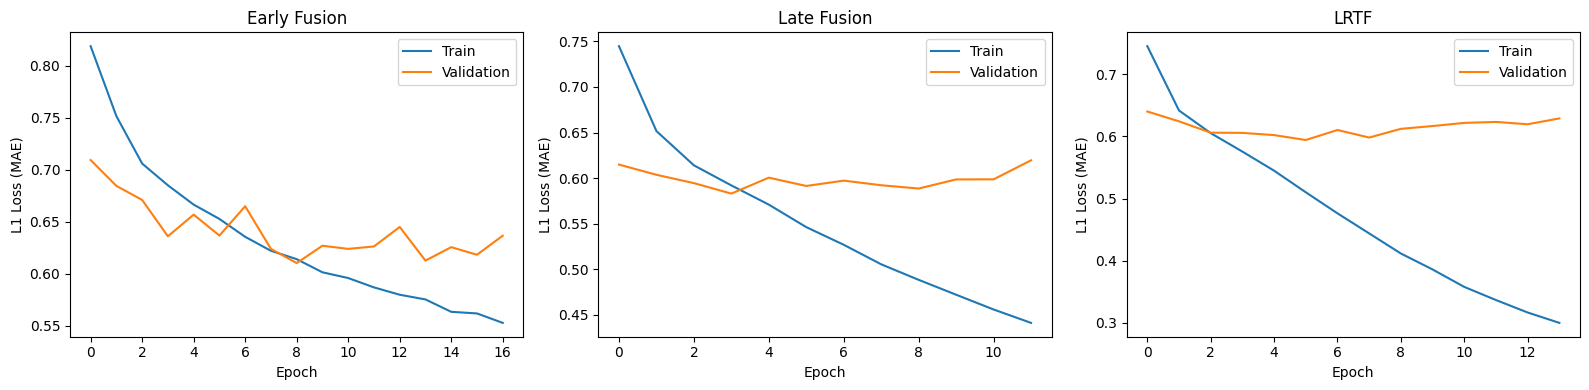

In [ ]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, th, vh, title in [
    (axes[0], ef_train_h,   ef_val_h,   "Early Fusion"),
    (axes[1], lf_train_h,   lf_val_h,   "Late Fusion"),
    (axes[2], lrtf_train_h, lrtf_val_h, "LRTF"),
]:
    ax.plot(th, label='Train')
    ax.plot(vh, label='Validation')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("L1 Loss (MAE)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/11_multimodal_training.png", bbox_inches='tight')
plt.show()

In [ ]:
# --- Save results ---
mm_save = {}
for name, metrics in [('Early Fusion', ef_metrics), ('Late Fusion', lf_metrics), ('LRTF', lrtf_metrics)]:
    mm_save[name] = dict(metrics)   # already contains preds + labels

with open("../results/multimodal_results.pkl", "wb") as f:
    pickle.dump(mm_save, f)

print("Saved to ../results/multimodal_results.pkl")

Saved to ../results/multimodal_results.pkl
